# Credit Risk Analysis — Lending Club (2007–2018)

**Business question:** *Which borrowers are likely to default, and how do we group them into risk tiers?*


## Imported the required libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## Loaded the data - the data used here is : https://www.kaggle.com/datasets/wordsforthewise/lending-club

In [2]:
cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti',
    'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'open_acc',
    'pub_rec', 'revol_util', 'total_acc'
]

df = pd.read_csv(
    'data/accepted_2007_to_2018Q4.csv.gz',
    usecols=cols,
    low_memory=False
)

print('Rows, Columns:', df.shape)
df.head()

Rows, Columns: (2260701, 22)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,pub_rec,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,debt_consolidation,PA,5.91,0.0,675.0,679.0,7.0,0.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,small_business,SD,16.06,1.0,715.0,719.0,22.0,0.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,Dec-2015,Fully Paid,home_improvement,IL,10.78,0.0,695.0,699.0,6.0,0.0,56.2,18.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,Dec-2015,Current,debt_consolidation,NJ,17.06,0.0,785.0,789.0,13.0,0.0,11.6,17.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,Dec-2015,Fully Paid,major_purchase,PA,25.37,1.0,695.0,699.0,12.0,0.0,64.5,35.0


## 3. CHECKED DATA TYPES


In [3]:
df.info()
print('\n% missing per column:')
(df.isna().mean() * 100).round(1).sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 22 columns):
 #   Column               Dtype  
---  ------               -----  
 0   loan_amnt            float64
 1   term                 str    
 2   int_rate             float64
 3   installment          float64
 4   grade                str    
 5   sub_grade            str    
 6   emp_length           str    
 7   home_ownership       str    
 8   annual_inc           float64
 9   verification_status  str    
 10  issue_d              str    
 11  loan_status          str    
 12  purpose              str    
 13  addr_state           str    
 14  dti                  float64
 15  delinq_2yrs          float64
 16  fico_range_low       float64
 17  fico_range_high      float64
 18  open_acc             float64
 19  pub_rec              float64
 20  revol_util           float64
 21  total_acc            float64
dtypes: float64(12), str(10)
memory usage: 379.5 MB

% missing per column:


emp_length             6.5
dti                    0.1
revol_util             0.1
int_rate               0.0
loan_amnt              0.0
term                   0.0
sub_grade              0.0
grade                  0.0
installment            0.0
home_ownership         0.0
issue_d                0.0
loan_status            0.0
annual_inc             0.0
verification_status    0.0
addr_state             0.0
purpose                0.0
fico_range_low         0.0
delinq_2yrs            0.0
fico_range_high        0.0
open_acc               0.0
pub_rec                0.0
total_acc              0.0
dtype: float64

## Created the target variable: `default`


In [4]:
print('All loan_status values:')
print(df['loan_status'].value_counts())

# Keep only finished loans with a clear good/bad outcome
good = ['Fully Paid']
bad = ['Charged Off', 'Default']

df = df[df['loan_status'].isin(good + bad)].copy()
df['default'] = df['loan_status'].isin(bad).astype(int)

print('\nRows after keeping finished loans:', df.shape[0])
print('Overall default rate: {:.2%}'.format(df['default'].mean()))

All loan_status values:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Rows after keeping finished loans: 1345350
Overall default rate: 19.96%


## Cleaned the key columns

- `term` → number of months (36 / 60)
- `emp_length` → number of years (0–10)
- `int_rate`, `revol_util` → already numeric in this file, but we coerce to be safe
- `issue_d` → a real date so we can analyze by year

In [5]:
# term: ' 36 months' -> 36
df['term'] = df['term'].str.extract(r'(\d+)').astype(float)

# emp_length: '10+ years' -> 10, '< 1 year' -> 0, '3 years' -> 3
df['emp_length'] = (df['emp_length']
                    .str.replace('10+ years', '10', regex=False)
                    .str.replace('< 1 year', '0', regex=False)
                    .str.extract(r'(\d+)').astype(float))

# Make sure numeric columns really are numeric
for c in ['int_rate', 'revol_util', 'dti', 'annual_inc']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# issue_d -> datetime, then pull out the year
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['issue_year'] = df['issue_d'].dt.year

# A single FICO score = midpoint of the low/high range
df['fico'] = (df['fico_range_low'] + df['fico_range_high']) / 2

print('Cleaning done.')
df[['term', 'emp_length', 'int_rate', 'dti', 'fico', 'issue_year']].describe()

Cleaning done.


,term,emp_length,int_rate,dti,fico,issue_year
count,1.345350e+06,1.266834e+06,1.345350e+06,1.344976e+06,1.345350e+06,1.345350e+06
mean,4.179029e+01,5.965847e+00,1.323971e+01,1.828264e+01,6.981853e+02,2.014972e+03
std,1.026838e+01,3.691171e+00,4.768782e+00,1.116041e+01,3.185312e+01,1.639698e+00
min,3.600000e+01,0.000000e+00,5.310000e+00,-1.000000e+00,6.270000e+02,2.007000e+03
25%,3.600000e+01,2.000000e+00,9.750000e+00,1.179000e+01,6.720000e+02,2.014000e+03
50%,3.600000e+01,6.000000e+00,1.274000e+01,1.761000e+01,6.920000e+02,2.015000e+03
75%,3.600000e+01,1.000000e+01,1.599000e+01,2.406000e+01,7.120000e+02,2.016000e+03
max,6.000000e+01,1.000000e+01,3.099000e+01,9.990000e+02,8.475000e+02,2.018000e+03


## Default patterns — the core analysis


In [6]:
def default_rate_by(column, sort_by_rate=False):
    """Default rate and loan count for each value of a column."""
    out = (df.groupby(column)['default']
             .agg(default_rate='mean', loans='count')
             .assign(default_rate=lambda x: (x['default_rate'] * 100).round(2)))
    if sort_by_rate:
        out = out.sort_values('default_rate', ascending=False)
    return out

### By loan grade (A = safest → G = riskiest)


       default_rate   loans
grade                      
A              6.04  235095
B             13.39  392748
C             22.44  381694
D             30.39  200966
E             38.48   93656
F             45.20   32059
G             49.93    9132


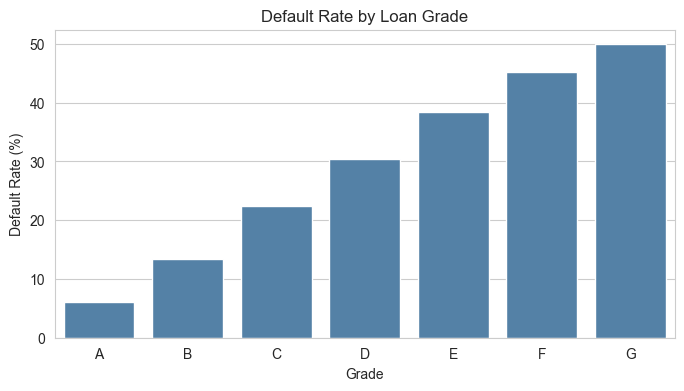

In [7]:
by_grade = default_rate_by('grade')
print(by_grade)

plt.figure(figsize=(8, 4))
sns.barplot(x=by_grade.index, y=by_grade['default_rate'], color='steelblue')
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate (%)'); plt.xlabel('Grade')
plt.show()

### By loan purpose


                    default_rate   loans
purpose                                 
small_business             29.71   15416
renewable_energy           23.69     933
moving                     23.35    9480
house                      21.89    7254
medical                    21.79   15556
debt_consolidation         21.15  780342
other                      21.04   77877
vacation                   19.17    9065
major_purchase             18.61   29427
home_improvement           17.72   87507
educational                17.18     326
credit_card                16.93  295285
car                        14.70   14588
wedding                    12.16    2294


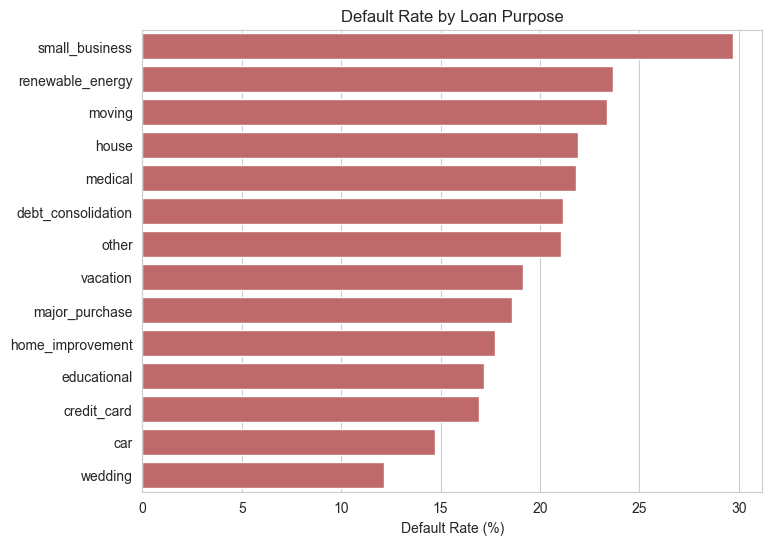

In [8]:
by_purpose = default_rate_by('purpose', sort_by_rate=True)
print(by_purpose)

plt.figure(figsize=(8, 6))
sns.barplot(y=by_purpose.index, x=by_purpose['default_rate'], color='indianred')
plt.title('Default Rate by Loan Purpose')
plt.xlabel('Default Rate (%)'); plt.ylabel('')
plt.show()

### By debt-to-income (DTI) band


In [9]:
df['dti_band'] = pd.cut(df['dti'],
                        bins=[-1, 10, 20, 30, 40, np.inf],
                        labels=['0-10', '10-20', '20-30', '30-40', '40+'])
print(default_rate_by('dti_band'))

          default_rate   loans
dti_band                      
0-10             14.89  246186
10-20            17.85  562128
20-30            23.05  408353
30-40            29.10  121541
40+              30.55    6766


###  By income band

In [10]:
df['income_band'] = pd.cut(df['annual_inc'],
                           bins=[0, 40000, 70000, 100000, 150000, np.inf],
                           labels=['<40k', '40-70k', '70-100k', '100-150k', '150k+'])
print(default_rate_by('income_band'))

             default_rate   loans
income_band                      
<40k                23.63  245589
40-70k              21.16  526360
70-100k             18.52  322993
100-150k            16.18  178922
150k+               14.58   71125


### By term and home ownership

In [11]:
print('By term (months):')
print(default_rate_by('term'))
print('\nBy home ownership:')
print(default_rate_by('home_ownership', sort_by_rate=True))

By term (months):
      default_rate    loans
term                       
36.0         16.00  1020768
60.0         32.45   324582

By home ownership:
                default_rate   loans
home_ownership                      
RENT                   23.22  534436
OWN                    20.62  144840
ANY                    19.58     286
OTHER                  18.75     144
MORTGAGE               17.21  665596
NONE                   14.58      48


## A little statistics: what moves with default?


Correlation with default (higher = more linked to defaulting):
int_rate       0.259
term           0.176
dti            0.084
loan_amnt      0.066
revol_util     0.060
delinq_2yrs    0.019
emp_length    -0.014
annual_inc    -0.042
fico          -0.131
Name: default, dtype: float64


C:\Users\Pankaj Kumar\AppData\Local\Temp\ipykernel_30244\418177725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')


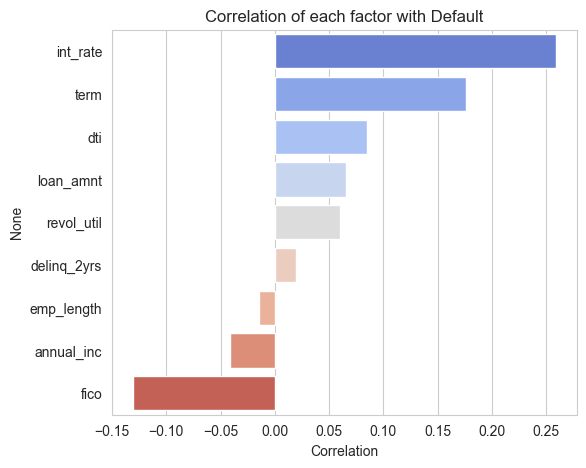

In [12]:
num_cols = ['default', 'int_rate', 'dti', 'fico', 'annual_inc',
            'loan_amnt', 'term', 'emp_length', 'revol_util', 'delinq_2yrs']
corr = df[num_cols].corr()['default'].drop('default').sort_values(ascending=False)
print('Correlation with default (higher = more linked to defaulting):')
print(corr.round(3))

plt.figure(figsize=(6, 5))
sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
plt.title('Correlation of each factor with Default')
plt.xlabel('Correlation'); plt.show()

## Built risk segments (Low / Medium / High)

              default_rate   loans
risk_segment                      
Low                  12.42  613598
Medium               24.08  583349
High                 34.99  148403


C:\Users\Pankaj Kumar\AppData\Local\Temp\ipykernel_30244\2697946664.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg.index, y=seg['default_rate'],


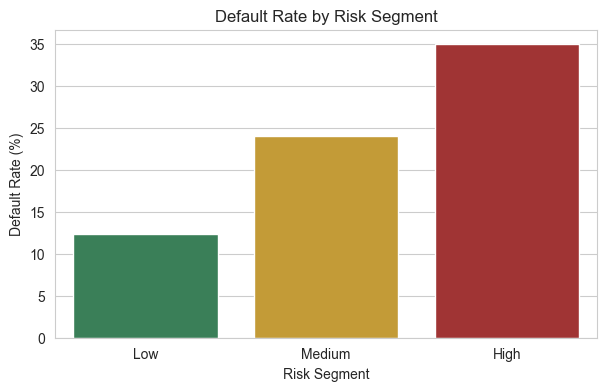

In [13]:
score = pd.Series(0, index=df.index)

# Grade: A/B safe (0), C/D medium (+1), E/F/G risky (+2)
score += df['grade'].map({'A':0,'B':0,'C':1,'D':1,'E':2,'F':2,'G':2}).fillna(1)
# High DTI
score += (df['dti'] > 25).astype(int)
# Low FICO
score += (df['fico'] < 680).astype(int)
# Past delinquencies
score += (df['delinq_2yrs'] > 0).astype(int)
# High credit utilisation
score += (df['revol_util'] > 60).astype(int)

df['risk_score'] = score
df['risk_segment'] = pd.cut(score, bins=[-1, 1, 3, 99],
                            labels=['Low', 'Medium', 'High'])

seg = default_rate_by('risk_segment')
print(seg)

plt.figure(figsize=(7, 4))
sns.barplot(x=seg.index, y=seg['default_rate'],
            palette={'Low':'seagreen','Medium':'goldenrod','High':'firebrick'})
plt.title('Default Rate by Risk Segment')
plt.ylabel('Default Rate (%)'); plt.xlabel('Risk Segment')
plt.show()

## Exported cleaned data for Power BI

In [15]:
export_cols = [
    'issue_year', 'loan_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'income_band', 'verification_status', 'purpose', 'addr_state',
    'dti', 'dti_band', 'fico', 'revol_util', 'delinq_2yrs',
    'loan_status', 'default', 'risk_score', 'risk_segment'
]

clean = df[export_cols].copy()

# Export integer-like columns as clean integers (no '.0') and use '\n' line
# endings so MySQL and Power BI load the file without type/whitespace errors.
for c in ['issue_year', 'term', 'emp_length', 'delinq_2yrs', 'risk_score']:
    clean[c] = clean[c].astype('Int64')

clean.to_csv('credit_risk_clean.csv', index=False, lineterminator='\n')
print('Saved credit_risk_clean.csv  —  shape:', clean.shape)
clean.head()

Saved credit_risk_clean.csv  —  shape: (1345350, 23)


,issue_year,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,income_band,verification_status,purpose,addr_state,dti,dti_band,fico,revol_util,delinq_2yrs,loan_status,default,risk_score,risk_segment
0,2015,3600.0,36,13.99,123.03,C,C4,10,MORTGAGE,55000.0,40-70k,Not Verified,debt_consolidation,PA,5.91,0-10,677.0,29.7,0,Fully Paid,0,2,Medium
1,2015,24700.0,36,11.99,820.28,C,C1,10,MORTGAGE,65000.0,40-70k,Not Verified,small_business,SD,16.06,10-20,717.0,19.2,1,Fully Paid,0,2,Medium
2,2015,20000.0,60,10.78,432.66,B,B4,10,MORTGAGE,63000.0,40-70k,Not Verified,home_improvement,IL,10.78,10-20,697.0,56.2,0,Fully Paid,0,0,Low
4,2015,10400.0,60,22.45,289.91,F,F1,3,MORTGAGE,104433.0,100-150k,Source Verified,major_purchase,PA,25.37,20-30,697.0,64.5,1,Fully Paid,0,5,High
5,2015,11950.0,36,13.44,405.18,C,C3,4,RENT,34000.0,<40k,Source Verified,debt_consolidation,GA,10.20,10-20,692.0,68.4,0,Fully Paid,0,2,Medium


## Summary

Fill these in with **your** numbers after running the notebook — these become your resume bullets and the text on your dashboard:

- Overall default rate: **19.96%**
- Grade G defaults at **6.04%** vs Grade A at **49.93%** (≈ 5.52× higher)
- Riskiest purpose: **Small Business** (**29.71%**)
- Borrowers with DTI 40+ default at **30.55%** vs **14.89%** for DTI 0–10
- High-risk segment default rate: **34.99%** vs Low-risk **12.42%**

**Business recommendation:** *Tighten approvals for E–G grades with DTI > 25, price risk into interest rates, and monitor the High-risk segment monthly.*